In [5]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import START, END, StateGraph
from pydantic import BaseModel
from dotenv import load_dotenv
from typing import TypedDict
import re
load_dotenv()

True

In [6]:
docs = PyPDFLoader("./documents/MCP.pdf").load()

In [7]:
chunks = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=40).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [8]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks,embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k":4})

In [9]:
llm = ChatOpenAI(model="gpt-4o-mini",temperature=0)

In [10]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [23]:
class State(TypedDict):
    question: str
    docs: list[Document]

    good_docs: list[Document]
    verdict: str
    reason: str
    
    strips: list[str]
    kept_strips: list[str]
    refined_context: str
    answer: str

In [24]:
def retrieve(state: State):
    q = state["question"]
    return {"docs":retriever.invoke(q)}

In [25]:
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt= ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a strict retrieval evaluator for RAG.\n
            You will be given ONE retrieved chunk and a question.\n
            Return a relevance score in  [0.0,1.0].\n
            - 1.0: chunk alone is sufficient to answer fully/mostly.\n
            - 0.0: chunk is irrelevant.\n
            Be conservative with high scores.\n
            Also return a short reason.\n
            Output JSON only""",
        ),
        ("human","Question :{question}\n\n Chunk::\n{chunk}")
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State):
    q= state["question"]
    scores: list[float] = []
    reasons: list[str] = []
    good: list[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question":q, "chunk":d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        if out.score>LOWER_TH:
            good.append(d)

        if any(s>UPPER_TH for s in scores):
            return {
                "good_docs": good,
                "verdict": "CORRECT",
                "reason": f"At least one retrieved chunk scored > {UPPER_TH}."
            }

        if len(scores)>0 and all(s<LOWER_TH for s in scores):
            why = "No chunk was sufficient."
            return {
                "good_docs": [],
                "verdict": "INCORRECT",
                "reason": f"ALl retrieved chunks scored < {LOWER_TH}. {why}"
            }

        why = "mixed relevance signals."

        return {
            "good_docs": good,
            "verdict": "AMBIGUOUS",
            "reason": f"No chunk scored > {UPPER_TH}, but not all were<{LOWER_TH}. {why}"
        }

        

In [26]:
def decompose_to_sentences(text: str):
    text = re.sub(r"\s+"," ",text).strip()
    sentences = re.split(r"(?<=[.!?])\s+",text)
    return [s.strip() for s in sentences if len(s.strip())>20]

class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """you are a strict relevance filter.\n
            Return  keep=true only if the sentence directly helps answer the question.\n
            Use ONLY the sentences. Output JSON only.""",
        ),
        ("human","QuestionL {question}\n\nSentence:\n{sentence}")
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state: State):
    q = state["question"]

    context = "\n\n".join(d.page_content for d in state['good_docs']).strip()

    strips = decompose_to_sentences(context)

    kept : list[str] = []

    for s in strips:
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips":strips,
        "kept_strips":kept,
        "refined_context":refined_context
    }

In [27]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a helpful tutor. Answer Only using the provided refined bullets.\n
            If the bullets are empty or insifficient, say: 'i don't know based ont eh provided books."""
        ),
        ("human","Question: {question} \n\nRefined context:\n {refined_context}"),
    ]
)

def generate(state: State):
    out = (answer_prompt | llm).invoke({"question":state["question"], "refined_context":state["refined_context"]})
    return {"answer":out.content}

In [28]:
def fail_node(state: State):
    return {"answer": f"FAIL: {state["reason"]}"}

def ambiguous_node(state: State):
    return {"answer": f"Ambiguous: {state["reason"]}"}

def route_after_eval(state: State):
    if state["verdict"] == "CORRECT":
        return "refine"
    if state["verdict"] == "INCORRECT":
        return "fail"
    else:
        return "ambiguous"


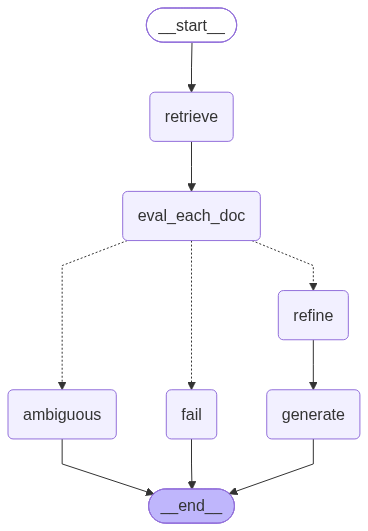

In [29]:
g = StateGraph(State)
g.add_node("retrieve",retrieve)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("refine",refine)
g.add_node("generate",generate)
g.add_node("fail", fail_node)
g.add_node("ambiguous", ambiguous_node)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")
g.add_conditional_edges("eval_each_doc",route_after_eval,{"refine":"refine","fail":"fail","ambiguous":"ambiguous"})
g.add_edge("refine","generate")
g.add_edge("generate",END)

app = g.compile()

app

In [30]:
res = app.invoke({
    "question":"What is MCP",
    "docs":[],
    "strips":[],
    "kept_strips":[],
    "refined_context":"",
})

print("Verdict:",res["verdict"])
print("Reason:",res["reason"])
print("\nOutput:\n",res["answer"])

Verdict: CORRECT
Reason: At least one retrieved chunk scored > 0.7.

Output:
 MCP (Model Context Protocol) is an open protocol that provides a standard way for AI applications to connect with external tools, data sources, and services.
